In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
import scipy.stats as stats
from scipy.stats import ttest_ind
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect("/content/drive/MyDrive/DA/inventory.db")

df = pd.read_sql_query("SELECT * from vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,TotalFreight,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,17035,PERNOD RICARD USA,2589,Jameson Irish Whiskey,30.76,1750,39.99,3169,97478.44,5622.52,835.78,148.0,271.95,123780.22,-91855.92,-1633.714420,0.046702,0.057680
1,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,1750,24.99,3331,60757.44,9349.02,986.58,398.0,731.31,123780.22,-51408.42,-549.880308,0.119484,0.153874
2,8112,MOET HENNESSY USA INC,6654,Veuve Clicquot Brut Yellow,27.20,750,39.99,1771,48171.20,4918.77,1279.68,123.0,13.78,48347.26,-43252.43,-879.334264,0.069452,0.102110
3,8112,MOET HENNESSY USA INC,7865,Moet & Chandon Imperial,23.97,750,34.99,1950,46741.50,3044.13,874.75,87.0,9.74,48347.26,-43697.37,-1435.463334,0.044615,0.065127
4,9165,ULTRA BEVERAGE COMPANY LLP,3650,Patron Silver Tequila,33.81,750,48.99,1279,43242.99,2547.48,783.84,52.0,40.93,68054.70,-40695.51,-1597.481040,0.040657,0.058911


In [ ]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,2091.0,11193.986609,16885.968996,653.000000,6785.000000,8673.000000,9815.000000,173357.000000
Brand,2091.0,17173.820182,13407.681330,58.000000,5110.000000,15047.000000,26216.500000,90631.000000
PurchasePrice,2091.0,15.198077,50.326844,0.380000,6.660000,9.650000,15.930000,2222.210000
ActualPrice,2091.0,22.132956,63.944668,0.490000,9.990000,14.990000,22.990000,2799.990000
TotalPurchaseQuantity,2091.0,163.943089,383.178947,1.000000,17.500000,47.000000,132.000000,6174.000000
TotalPurchaseDollars,2091.0,1736.275691,4595.322269,0.720000,179.535000,496.320000,1440.680000,97478.440000
TotalSalesDollars,1058.0,354.689263,718.691985,4.950000,76.187500,160.930000,349.807500,9885.590000
TotalSalesPrice,1058.0,160.193440,178.328239,3.960000,53.917500,103.920000,194.902500,1399.900000
TotalSalesQuantity,1058.0,25.761815,50.461840,1.000000,5.000000,10.000000,25.000000,772.000000
TotalExciseTax,1058.0,14.049745,46.496540,0.060000,1.002500,3.150000,10.240000,731.310000


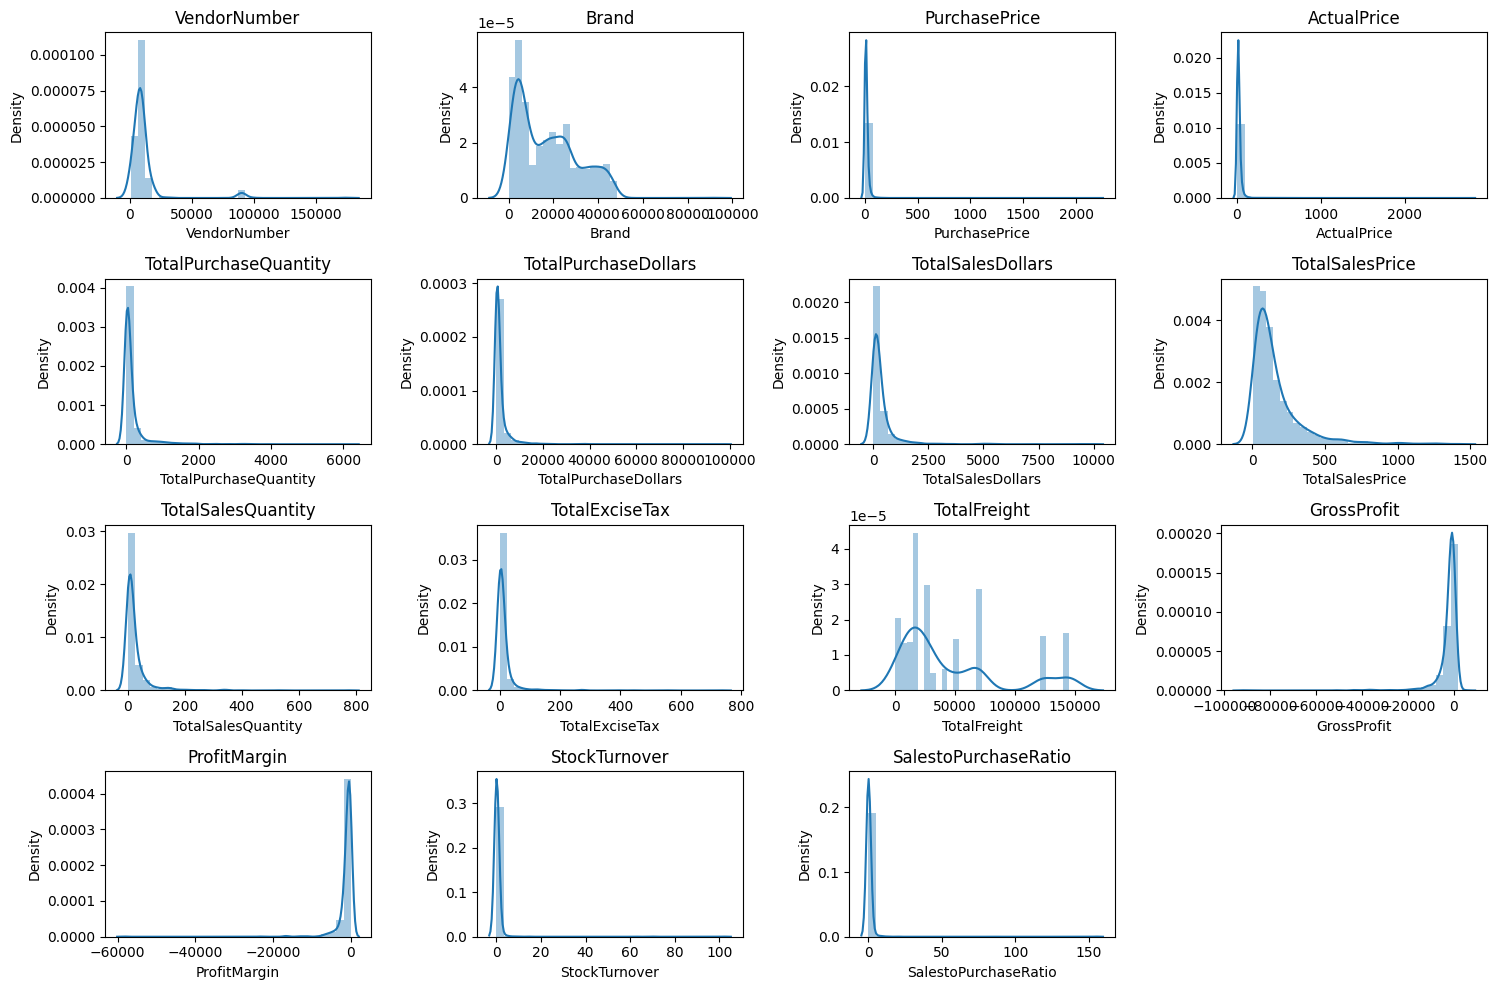

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i , col in enumerate(numerical_cols):
  plt.subplot(4, 4,i+1)
  sns.distplot(df[col], kde=True, bins=30)
  plt.title(col)
plt.tight_layout()
plt.show()

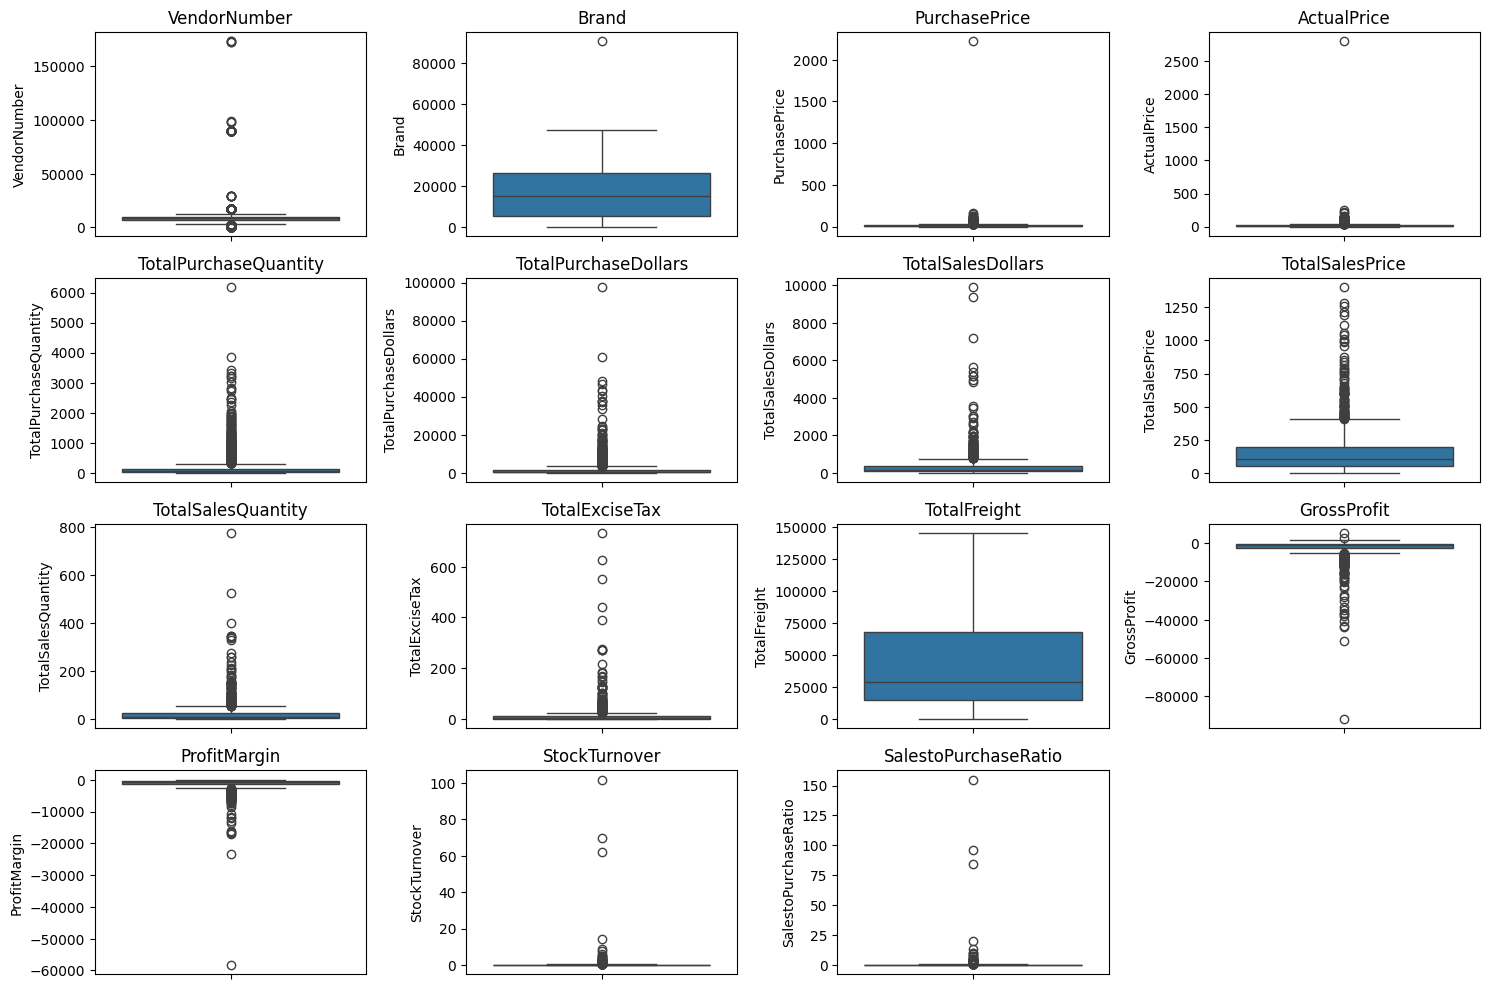

In [ ]:
plt.figure(figsize=(15,10))
for i , col in enumerate(numerical_cols):
  plt.subplot(4, 4,i+1)
  sns.boxplot(y = df[col])
  plt.title(col)
plt.tight_layout()
plt.show()

In [3]:
print(conn.execute("PRAGMA database_list").fetchall())

print(pd.read_sql_query(
    "PRAGMA table_info(vendor_sales_summary)",
    conn
))

[(0, 'main', '/content/drive/MyDrive/DA/inventory.db')]
    cid                   name     type  notnull dflt_value  pk
0     0           VendorNumber  INTEGER        0       None   0
1     1             VendorName     TEXT        0       None   0
2     2                  Brand  INTEGER        0       None   0
3     3            Description     TEXT        0       None   0
4     4          PurchasePrice     REAL        0       None   0
5     5                 Volume     TEXT        0       None   0
6     6            ActualPrice     REAL        0       None   0
7     7  TotalPurchaseQuantity  INTEGER        0       None   0
8     8   TotalPurchaseDollars     REAL        0       None   0
9     9      TotalSalesDollars     REAL        0       None   0
10   10        TotalSalesPrice     REAL        0       None   0
11   11     TotalSalesQuantity     REAL        0       None   0
12   12         TotalExciseTax     REAL        0       None   0
13   13           TotalFreight     REAL        0

In [4]:
# filter data by removing inconsistencies

df = pd.read_sql_query("""SELECT * from vendor_sales_summary WHERE
GrossProfit > 0
and ProfitMargin> 0
and TotalSalesQuantity > 0 """,conn)
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,TotalFreight,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,1750,28.99,205,4753.95,9885.59,637.78,341.0,626.58,144929.24,5131.64,51.910306,1.663415,2.079448
1,4425,MARTIGNETTI COMPANIES,14672,Duckhorn Decoy Cab Svgn,11.61,750,21.99,58,673.38,796.65,271.20,47.0,5.26,144929.24,123.27,15.473545,0.810345,1.183062
2,4425,MARTIGNETTI COMPANIES,27202,DeLoach Sonoma Cnty Chard,6.80,750,9.99,91,618.80,1508.49,229.77,151.0,16.95,144929.24,889.69,58.978846,1.659341,2.437767
3,4425,MARTIGNETTI COMPANIES,11214,Caymus Cab Svgn Napa Vly,50.33,750,74.99,12,603.96,769.89,629.91,11.0,1.21,144929.24,165.93,21.552430,0.916667,1.274737
4,4425,MARTIGNETTI COMPANIES,36770,Yellow Tail Cab Svgn Ausl,6.13,1500,9.99,82,502.66,1171.82,173.17,130.0,29.23,144929.24,669.16,57.104333,1.585366,2.331238
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,4425,MARTIGNETTI COMPANIES,15355,Decoy Duckhorn Chard Sonoma,9.12,750,15.99,1,9.12,67.80,33.90,4.0,0.44,144929.24,58.68,86.548673,4.000000,7.434211
71,7255,PSP WINES,24520,I Lauri Spumante Brut Rose,8.96,750,12.99,1,8.96,77.94,38.97,6.0,0.67,648.71,68.98,88.503977,6.000000,8.698661
72,8004,SAZERAC CO INC,5828,Ryans Irish Cream,6.61,750,8.99,1,6.61,557.38,296.67,62.0,48.79,50293.62,550.77,98.814095,62.000000,84.323752
73,6785,PALM BAY INTERNATIONAL INC,43432,Montgras RSV Svgn Bl Casabln,3.94,750,5.99,1,3.94,610.98,125.79,102.0,11.45,13605.41,607.04,99.355134,102.000000,155.071066


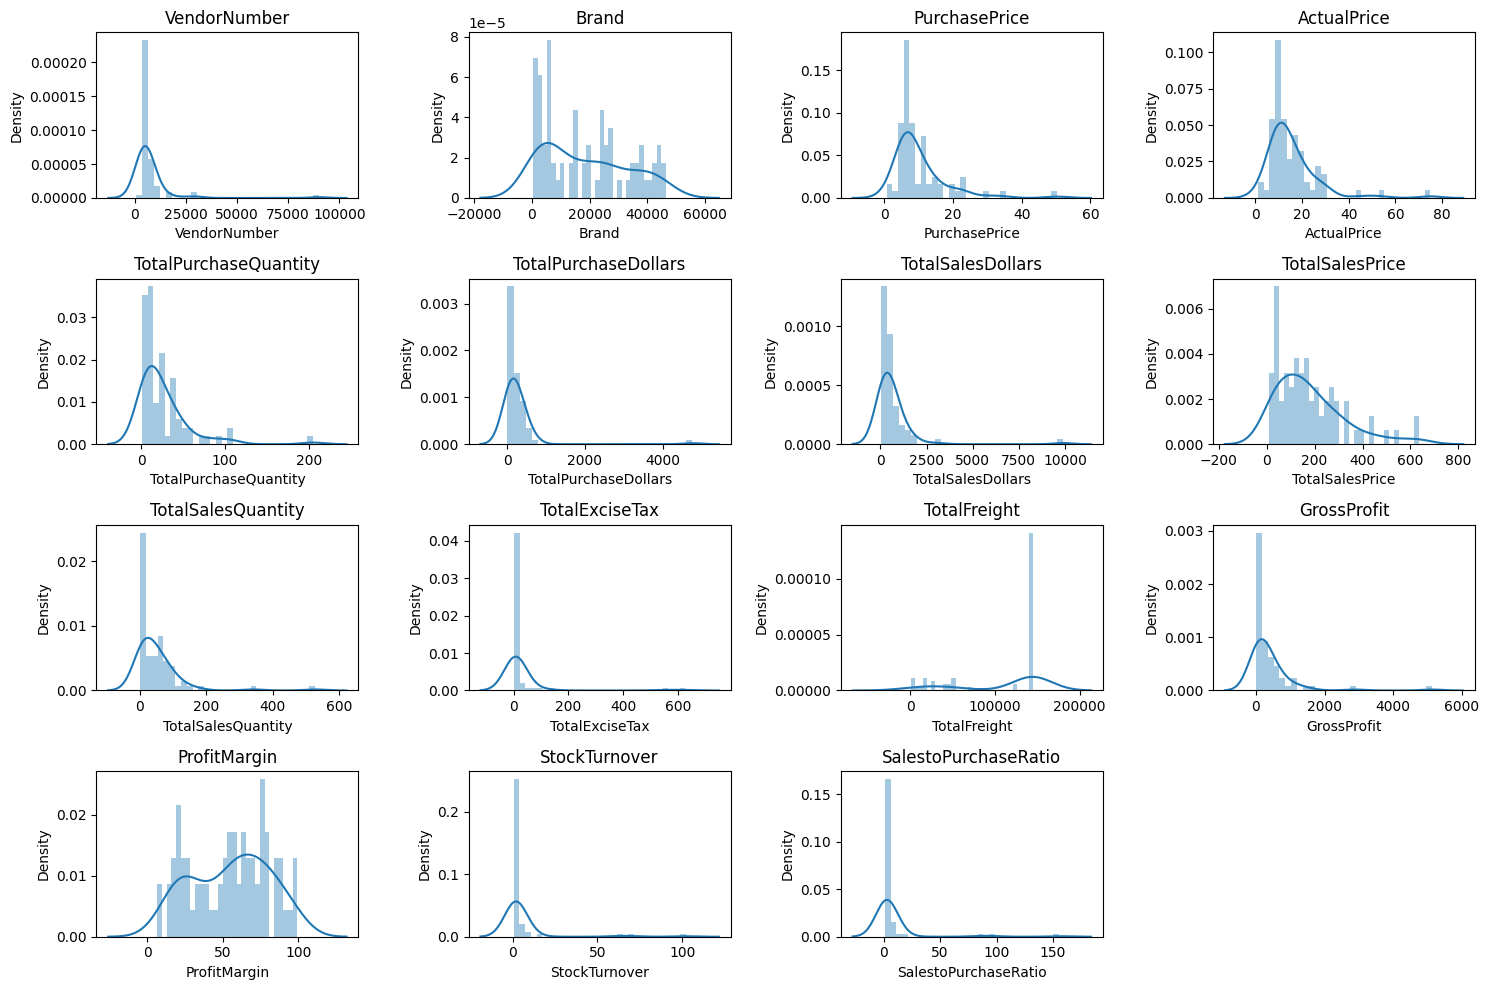

In [5]:
numerical_cols = df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i , col in enumerate(numerical_cols):
  plt.subplot(4, 4,i+1)
  sns.distplot(df[col], kde=True, bins=30)
  plt.title(col)
plt.tight_layout()
plt.show()

In [ ]:
print(df.columns.tolist())

['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice', 'Volume', 'ActualPrice', 'TotalPurchaseQuantity', 'TotalPurchaseDollars', 'TotalSalesDollars', 'TotalSalesPrice', 'TotalSalesQuantity', 'TotalExciseTax', 'TotalFreight', 'GrossProfit', 'ProfitMargin', 'StockTurnover', 'SalestoPurchaseRatio']


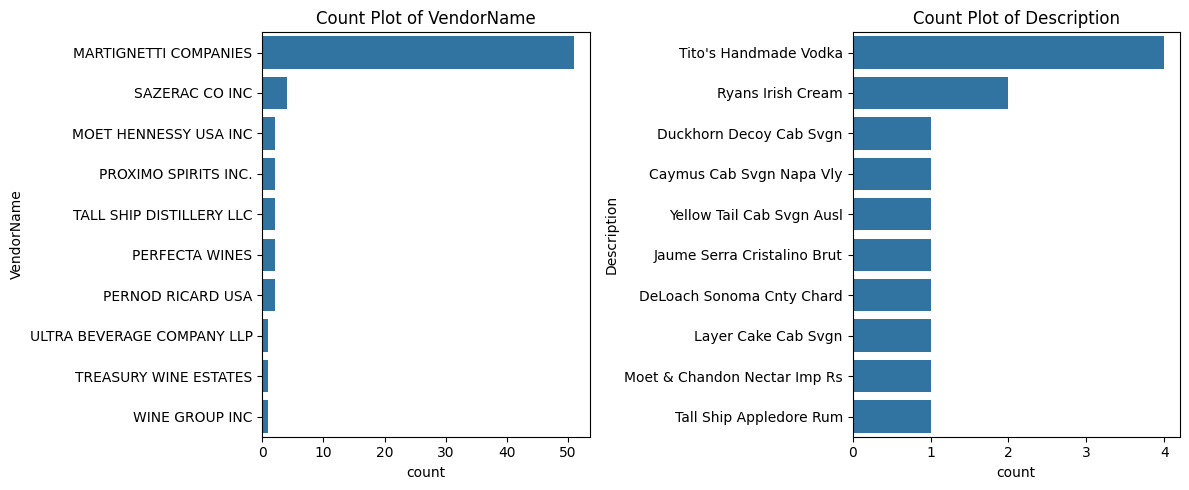

In [6]:
# count plot for categorical columns
categorical_col = ["VendorName","Description"]

plt.figure(figsize=(12,5))
for i , col in enumerate(categorical_col):
  plt.subplot(1, 2, i+1)
  sns.countplot(y = df[col], order = df[col].value_counts().index[:10]) # Top 10 categories
  plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

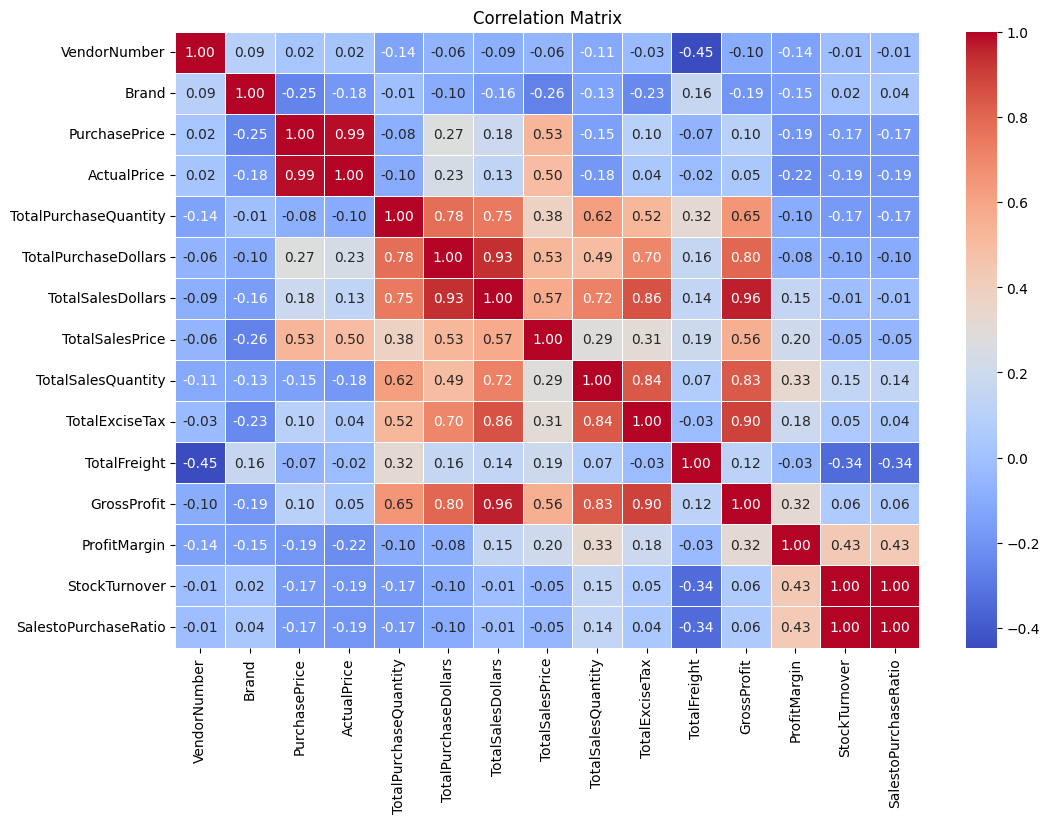

In [7]:
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt = '.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

# **Data Analysis**
Identify Brands that needs pricing adjustments which exhibit lower sales performance but higher profit margins

In [8]:
brand_performance = df.groupby('Description').agg(
    {
        'TotalSalesDollars':'sum',
        'ProfitMargin':'mean'
    }
).reset_index()

In [9]:
print("Sales 15% quantile:")
print(brand_performance['TotalSalesDollars'].quantile(0.15))

print("\nProfit Margin 85% quantile:")
print(brand_performance['ProfitMargin'].quantile(0.85))

Sales 15% quantile:
80.935

Profit Margin 85% quantile:
83.102073155754


In [10]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(.15)
high_margin_threshold = brand_performance['ProfitMargin'].quantile(.85)



In [ ]:
low_sales_threshold

np.float64(80.935)

In [ ]:
high_margin_threshold

np.float64(83.102073155754)

In [11]:
# Filter Brand with low sales but high performance

target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with low sales but high performance:")
print(target_brands.sort_values('TotalSalesDollars'))

Brands with low sales but high performance:
                    Description  TotalSalesDollars  ProfitMargin
21  Decoy Duckhorn Chard Sonoma              67.80     86.548673
2   Blue Chair Bay Banana Cream              69.30     98.961039
30   I Lauri Spumante Brut Rose              77.94     88.503977


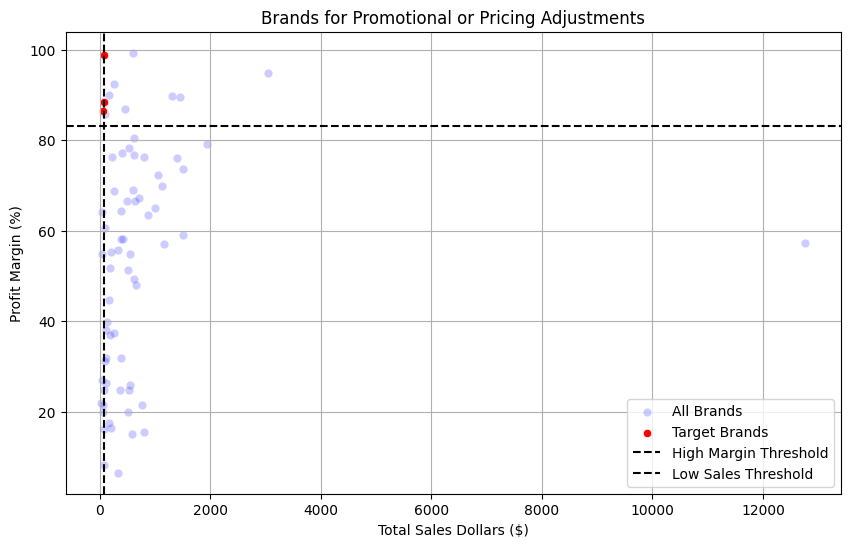

In [12]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=brand_performance,x='TotalSalesDollars',y='ProfitMargin',color='blue',label='All Brands',alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars',y='ProfitMargin',color='red',label='Target Brands')

plt.axhline(high_margin_threshold,linestyle='--',color='black',label='High Margin Threshold')
plt.axvline(low_sales_threshold,linestyle='--',color='black',label='Low Sales Threshold')


plt.title('Brands for Promotional or Pricing Adjustments')
plt.xlabel('Total Sales Dollars ($)')
plt.ylabel('Profit Margin (%)')
plt.legend()
plt.grid(True)

plt.show()

Which vendors and brands demonstrate the highest sales performance?

In [13]:
def format_dollars(value):
  if value >= 1_000_000:
    return f"{value/1_000_000:.2f}M"
  elif value >= 1000:
    return f"{value/1000:.2f}K"
  else:
    return str(value)


In [14]:
# Top vendor and brand by sales performance
top_vendors = df.groupby('VendorName')["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby('Description')["TotalSalesDollars"].sum().nlargest(10)
top_vendors


,TotalSalesDollars
VendorName,
MARTIGNETTI COMPANIES,39460.87
SAZERAC CO INC,4546.33
TALL SHIP DISTILLERY LLC,1035.63
MOET HENNESSY USA INC,805.80
TREASURY WINE ESTATES,659.45
ULTRA BEVERAGE COMPANY LLP,615.23
PALM BAY INTERNATIONAL INC,610.98
PROXIMO SPIRITS INC.,380.87
PERFECTA WINES,291.78


In [15]:
top_brands.apply(lambda x : format_dollars(x))

,TotalSalesDollars
Description,
Tito's Handmade Vodka,12.77K
Bowman's Vodka,3.05K
Santa Margherita Pnt Grigio,1.95K
Chalk Hill Pnt Nr Sonoma Cst,1.51K
DeLoach Sonoma Cnty Chard,1.51K
Ryans Irish Cream,1.45K
Bogle Merlot,1.40K
Luksusowa Potato Vodka,1.31K
Yellow Tail Cab Svgn Ausl,1.17K


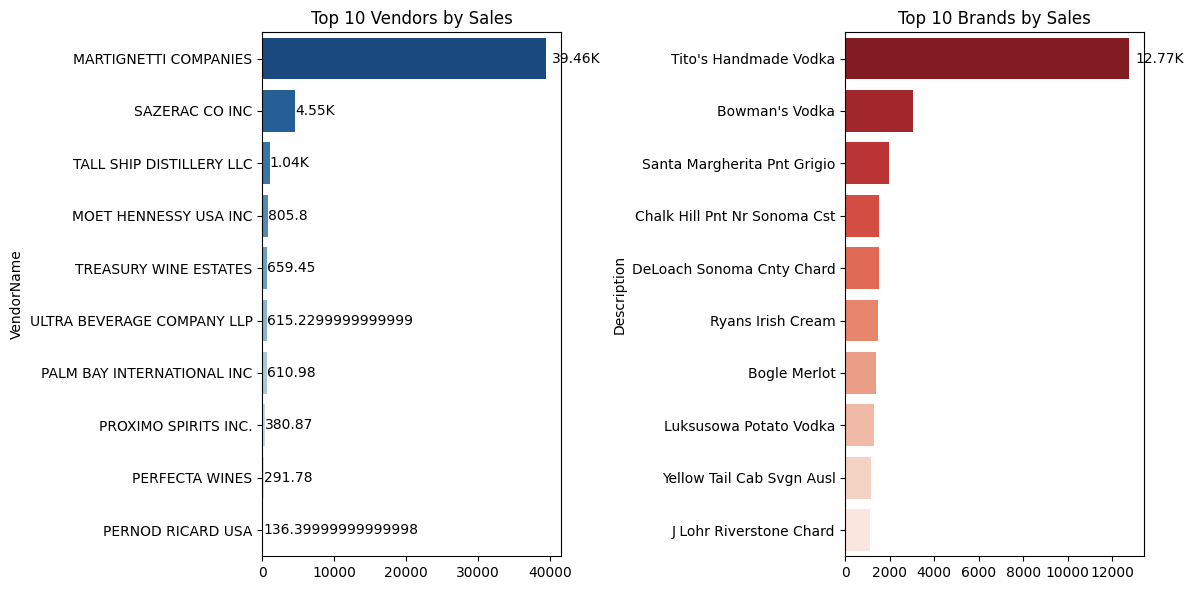

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [16]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
ax1 = sns.barplot(y=top_vendors.index,x=top_vendors.values,palette='Blues_r')
plt.title('Top 10 Vendors by Sales')

for bar in ax1.patches:
  ax1.text(bar.get_width()+(bar.get_width()*.02),
           bar.get_y()+bar.get_height()/2,
           format_dollars(bar.get_width()),
           ha='left',
           va='center',
           fontsize= 10, color = 'black'
           )

plt.subplot(1,2,2)
ax2 = sns.barplot(y=top_brands.index.astype(str),x=top_brands.values,palette='Reds_r')
plt.title('Top 10 Brands by Sales')

for bar in ax2.patches:
  ax2.text(bar.get_width()+(bar.get_width()*.02),
           bar.get_y()+bar.get_height()/2,
           format_dollars(bar.get_width()),
           ha='left',
           va='center',
           fontsize= 10, color = 'black'
           )

  plt.tight_layout()
  plt.show()

Which vendors contribute the most to total purchase dollars

In [17]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape


(17, 4)

In [18]:
vendor_performance["PurchaseContribution%"] = (
    vendor_performance['TotalPurchaseDollars']
    / vendor_performance['TotalPurchaseDollars'].sum()
) * 100
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

In [19]:
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,MARTIGNETTI COMPANIES,16.07K,23.39K,39.46K,85.99
12,TALL SHIP DISTILLERY LLC,644.94,390.69,1.04K,3.45
2,MOET HENNESSY USA INC,427.54,378.26,805.8,2.29
9,SAZERAC CO INC,374.62,4.17K,4.55K,2.00
13,TREASURY WINE ESTATES,343.57,315.88,659.45,1.84
6,PROXIMO SPIRITS INC.,287.01,93.86,380.87,1.54
14,ULTRA BEVERAGE COMPANY LLP,120.06,495.17,615.23,0.64
4,PERFECTA WINES,95.42,196.36,291.78,0.51
16,WINE GROUP INC,81.72,38.14,119.86,0.44
10,SAZERAC NORTH AMERICA INC.,66.0,29.88,95.88,0.35


In [20]:
top_vendors['Cumulative_contibution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_contibution%
0,MARTIGNETTI COMPANIES,16.07K,23.39K,39.46K,85.99,85.99
12,TALL SHIP DISTILLERY LLC,644.94,390.69,1.04K,3.45,89.44
2,MOET HENNESSY USA INC,427.54,378.26,805.8,2.29,91.73
9,SAZERAC CO INC,374.62,4.17K,4.55K,2.00,93.73
13,TREASURY WINE ESTATES,343.57,315.88,659.45,1.84,95.57
6,PROXIMO SPIRITS INC.,287.01,93.86,380.87,1.54,97.11
14,ULTRA BEVERAGE COMPANY LLP,120.06,495.17,615.23,0.64,97.75
4,PERFECTA WINES,95.42,196.36,291.78,0.51,98.26
16,WINE GROUP INC,81.72,38.14,119.86,0.44,98.70
10,SAZERAC NORTH AMERICA INC.,66.0,29.88,95.88,0.35,99.05


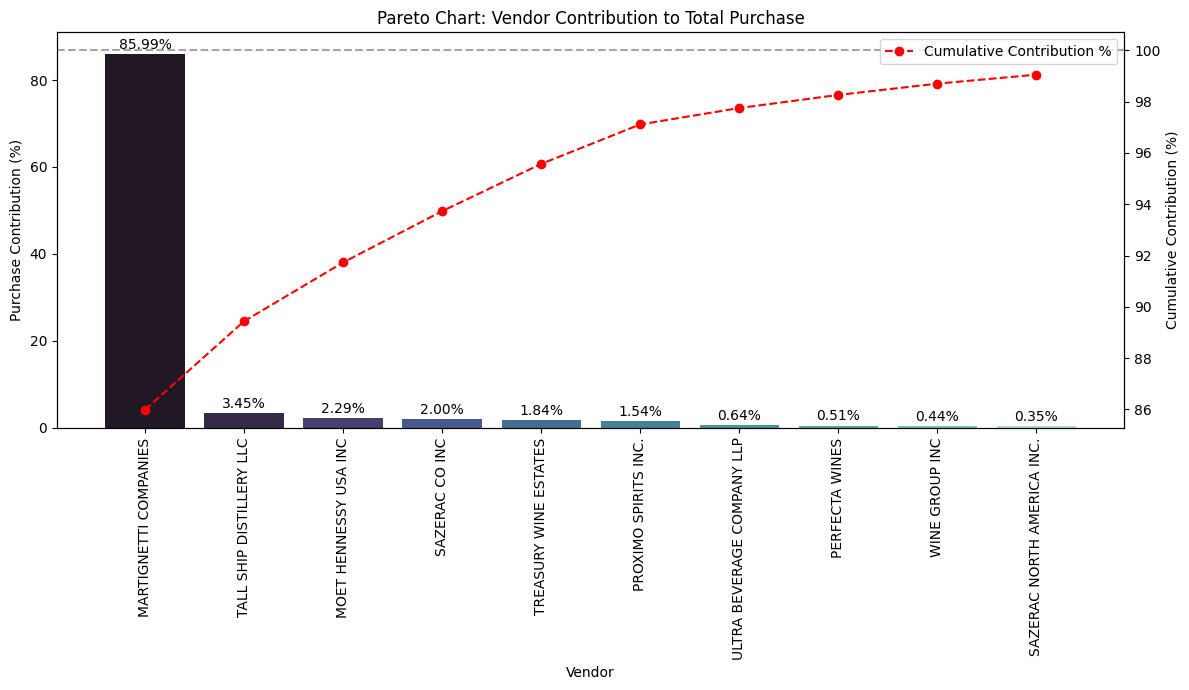

In [33]:
fig, ax1 = plt.subplots(figsize=(12, 7))

sns.barplot(
    x='VendorName',
    y='PurchaseContribution%',
    data=top_vendors,
    palette='mako',
    ax=ax1
)

# Add percentage labels
for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(
        i,
        value + 0.5,          # put text slightly ABOVE the bar
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

# Cumulative contribution line
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_contibution%'],
    color='red',
    marker='o',
    linestyle='dashed',
    label='Cumulative Contribution %'
)

# Labels
ax1.set_xticklabels(
    top_vendors['VendorName'],
    rotation=90
)

ax1.set_ylabel('Purchase Contribution (%)')
ax2.set_ylabel('Cumulative Contribution (%)')
ax1.set_xlabel('Vendor')

ax1.set_title(
    'Pareto Chart: Vendor Contribution to Total Purchase'
)

# Give space above bars
ax1.set_ylim(
    0,
    top_vendors['PurchaseContribution%'].max() + 5
)

# 100% reference line
ax2.axhline(
    100,
    color='gray',
    linestyle='--',
    alpha=0.7
)

ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

**How much of total Procurement is dependent on the top vendors**

In [34]:
print(f"Total Purchase COntribution of top 10 vendor is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

Total Purchase COntribution of top 10 vendor is 99.05 %


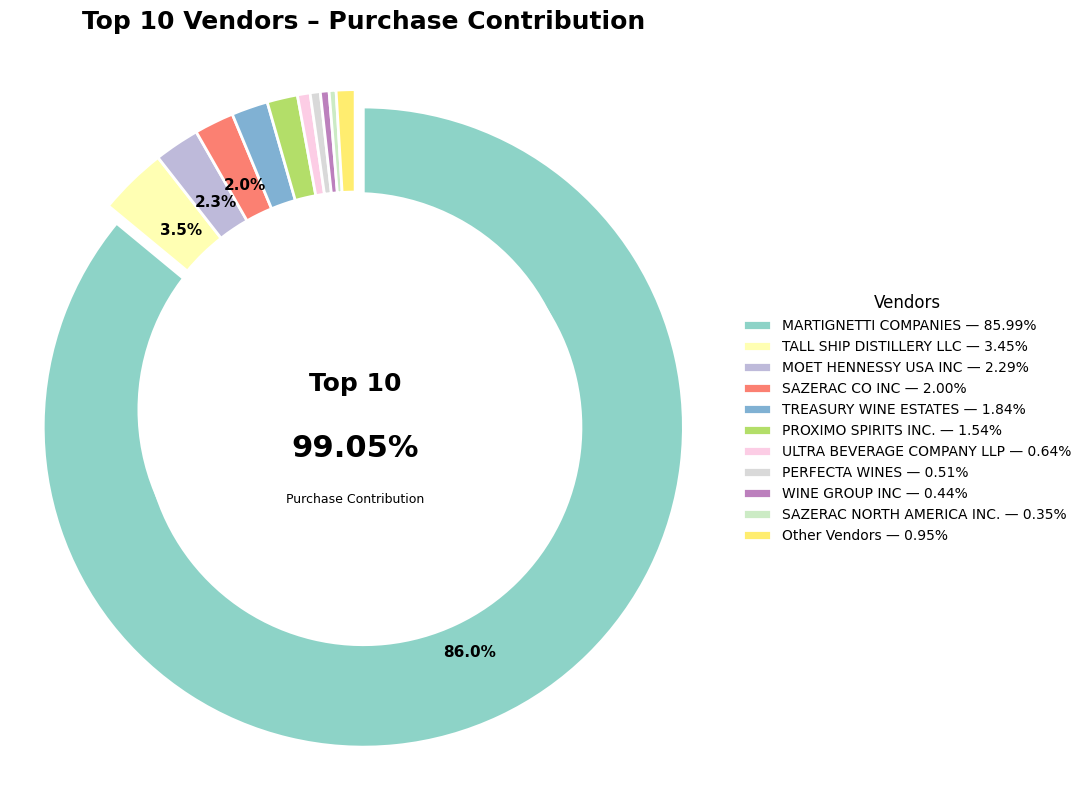

In [39]:
import matplotlib.pyplot as plt
import numpy as np

vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

vendors.append('Other Vendors')
purchase_contributions.append(remaining_contribution)

# ---------------------------------------------------
# Highlight the largest vendor
# ---------------------------------------------------
max_index = np.argmax(purchase_contributions)

explode = [0] * len(purchase_contributions)
explode[max_index] = 0.06

# ---------------------------------------------------
# Create figure
# ---------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 8))

# Use a clean colormap
colors = plt.cm.Set3(np.linspace(0, 1, len(purchase_contributions)))

# Donut chart
wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=None,
    autopct=lambda p: f'{p:.1f}%' if p >= 2 else '',
    startangle=90,
    counterclock=False,
    pctdistance=0.78,
    explode=explode,
    colors=colors,
    wedgeprops=dict(
        width=0.32,
        edgecolor='white',
        linewidth=2
    ),
    textprops=dict(
        fontsize=11,
        fontweight='bold'
    )
)

# ---------------------------------------------------
# Center circle
# ---------------------------------------------------
centre_circle = plt.Circle(
    (0, 0),
    0.68,
    fc='white'
)

ax.add_artist(centre_circle)

# ---------------------------------------------------
# Center text
# ---------------------------------------------------
ax.text(
    0,
    0.08,
    "Top 10",
    ha='center',
    va='center',
    fontsize=18,
    fontweight='bold'
)

ax.text(
    0,
    -0.12,
    f"{total_contribution:.2f}%",
    ha='center',
    va='center',
    fontsize=22,
    fontweight='bold'
)

ax.text(
    0,
    -0.28,
    "Purchase Contribution",
    ha='center',
    va='center',
    fontsize=9
)

# ---------------------------------------------------
# Legend
# ---------------------------------------------------
legend_labels = [
    f"{vendor} — {value:.2f}%"
    for vendor, value in zip(vendors, purchase_contributions)
]

ax.legend(
    wedges,
    legend_labels,
    title="Vendors",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    fontsize=10,
    title_fontsize=12,
    frameon=False
)

# ---------------------------------------------------
# Title
# ---------------------------------------------------
ax.set_title(
    "Top 10 Vendors – Purchase Contribution",
    fontsize=18,
    fontweight='bold',
    pad=20
)

# Keep circle perfectly round
ax.axis('equal')

plt.tight_layout()
plt.show()

In [41]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']


In [43]:
df['OrderSize'] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [50]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,10.9388
Medium,12.0352
Large,7.7748


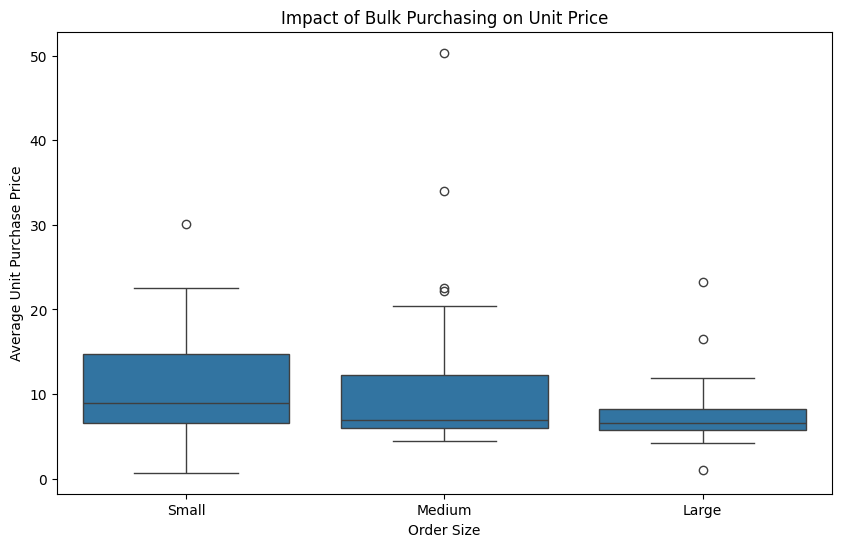

In [54]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='OrderSize', y='UnitPurchasePrice')
plt.title('Impact of Bulk Purchasing on Unit Price')
plt.xlabel('Order Size')
plt.ylabel('Average Unit Purchase Price')
plt.show()

**Which vendors have low inventory turnover, indicating excess stock and slow-moving products**

In [61]:
df[df['StockTurnover'] < 1]. groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)

,StockTurnover
VendorName,
VINILANDIA USA,0.700000
REMY COINTREAU USA INC,0.750000
MARTIGNETTI COMPANIES,0.761763
WINE GROUP INC,0.777778
MOET HENNESSY USA INC,0.916667


**How much capital is locked in unsold inventory and which vendors contribution the most to it?**

In [63]:
df["UnsoldInventory"] = (df["TotalSalesQuantity"] - df["TotalPurchaseQuantity"] )*df["PurchasePrice"]

print("Total Unsold Inventory: ", format_dollars(df["UnsoldInventory"].sum()))

Total Unsold Inventory:  15.10K


In [64]:
inventory_value_per_vendor = df.groupby('VendorName')[['UnsoldInventory']].sum().reset_index()
inventory_value_per_vendor = inventory_value_per_vendor.sort_values('UnsoldInventory',ascending=False)
inventory_value_per_vendor['UnsoldInventory'] = inventory_value_per_vendor['UnsoldInventory'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventory
0,MARTIGNETTI COMPANIES,10.93K
9,SAZERAC CO INC,2.94K
3,PALM BAY INTERNATIONAL INC,397.94
14,ULTRA BEVERAGE COMPANY LLP,281.88
12,TALL SHIP DISTILLERY LLC,144.79
2,MOET HENNESSY USA INC,121.35000000000002
13,TREASURY WINE ESTATES,95.88
5,PERNOD RICARD USA,66.7
4,PERFECTA WINES,63.92
1,MHW LTD,49.68


In [65]:
top_threshold = df["TotalSalesDollars"].quantile(.75)
low_threshold = df["TotalSalesDollars"].quantile(.25)

In [66]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

In [68]:
low_vendors

,ProfitMargin
49,31.820457
50,26.289926
52,39.763421
53,8.209222
54,38.063063
55,31.163955
56,16.243264
59,19.917562
60,24.739257
61,21.534612


In [70]:
def confidence_interval(data, confidence=.95):
  mean_val = np.mean(data)
  std_err = np.std(data, ddof=1) / np.sqrt(len(data))

  t_critical = stats.t.ppf((1+confidence) / 2, df = len(data) - 1)
  margin_of_error = t_critical * std_err
  return mean_val,mean_val - margin_of_error, mean_val + margin_of_error


Top Vendors 95% Confidence Interval: (56.13 , 75.26), Mean:65.695310
Low Vendors 95% Confidence Interval: (30.93 , 58.10), Mean:44.514484


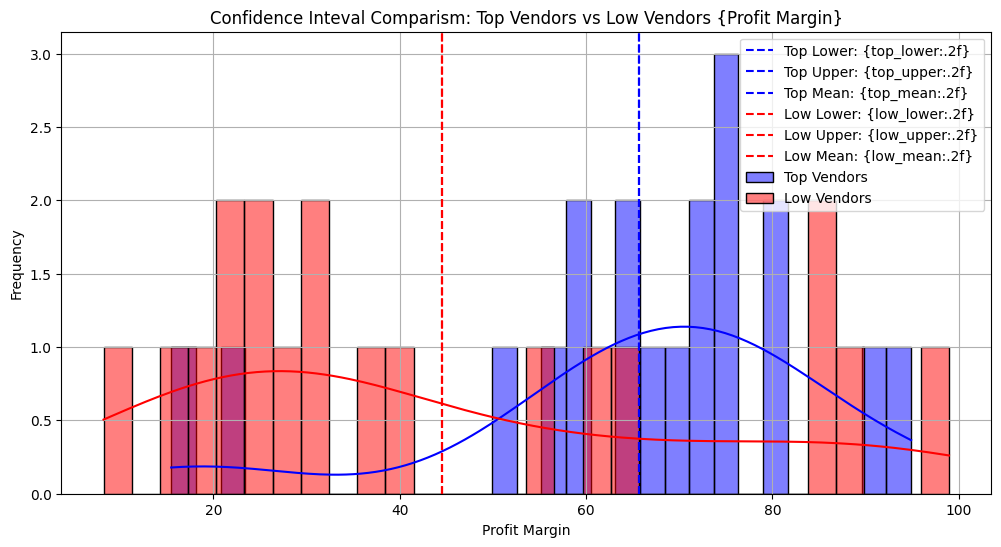

In [73]:
top_mean,top_lower,top_upper = confidence_interval(top_vendors)
low_mean,low_lower,low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% Confidence Interval: ({top_lower:.2f} , {top_upper:.2f}), Mean:{top_mean:2f}")
print(f"Low Vendors 95% Confidence Interval: ({low_lower:.2f} , {low_upper:.2f}), Mean:{low_mean:2f}")

plt.figure(figsize=(12,6))

sns.histplot(top_vendors,kde=True,color='blue',bins= 30, alpha=.5, label='Top Vendors')
plt.axvline(top_mean,color='blue',linestyle='--',label='Top Lower: {top_lower:.2f}')
plt.axvline(top_mean,color='blue',linestyle='--',label='Top Upper: {top_upper:.2f}')
plt.axvline(top_mean,color='blue',linestyle='--',label='Top Mean: {top_mean:.2f}')


sns.histplot(low_vendors,kde=True,color='red',bins= 30, alpha=.5,label='Low Vendors')
plt.axvline(low_mean,color='red',linestyle='--',label='Low Lower: {low_lower:.2f}')
plt.axvline(low_mean,color='red',linestyle='--',label='Low Upper: {low_upper:.2f}')
plt.axvline(low_mean,color='red',linestyle='--',label='Low Mean: {low_mean:.2f}')

plt.legend()
plt.title('Confidence Inteval Comparism: Top Vendors vs Low Vendors {Profit Margin}')
plt.xlabel('Profit Margin')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()


In [74]:
top_threshold = df["TotalSalesDollars"].quantile(.75)
low_threshold = df["TotalSalesDollars"].quantile(.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()


t_stat,p_value = ttest_ind(top_vendors,low_vendors,equal_var=False)

print(f"T-statistic: {t_stat:.4f}, p-Value: {p_value:.4f}")
if p_value < 0.05:
  print("Reject H0: There is a significant difference in Profit margins between top and low-performing vendors.")

else:
  print("Fail to Reject H0: No significant differnce in profit margins.")

T-statistic: 2.6778, p-Value: 0.0116
Reject H0: There is a significant difference in Profit margins between top and low-performing vendors.
